In [97]:
from google import genai
from google.genai import types
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import umap
from datasets import load_dataset
import pacmap
import random

In [98]:
ds = load_dataset("qwedsacf/competition_math")

In [99]:
client = genai.Client()

In [100]:
indices = random.sample(range(len(ds['train'])), 99)

texts = [ds['train']['problem'][i] for i in indices]
colors_type = [ds['train']['type'][i] for i in indices]
colors_level = [ds['train']['type'][i] for i in indices]

In [101]:
result = [
    np.array(e.values) for e in client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts,
        config=types.EmbedContentConfig(task_type="CLUSTERING")).embeddings
]

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

for i, text1 in enumerate(texts):
    for j in range(i + 1, len(texts)):
        text2 = texts[j]
        similarity = similarity_matrix[i, j]
        print(f"Similarity between '{text1}' and '{text2}': {similarity:.4f}")

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 100, model: gemini-embedding-1.0\nPlease retry in 33.822888538s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/embed_content_free_tier_requests', 'quotaId': 'EmbedContentRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-embedd

### UMAP

In [ ]:
unique_types = list(set(colors_level)) # colors_level
color_map = {type_name: i for i, type_name in enumerate(unique_types)}
color_values = [color_map[c] for c in colors_level] # colors_level

/Users/shreyanakum/Documents/knowledge-gaps/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


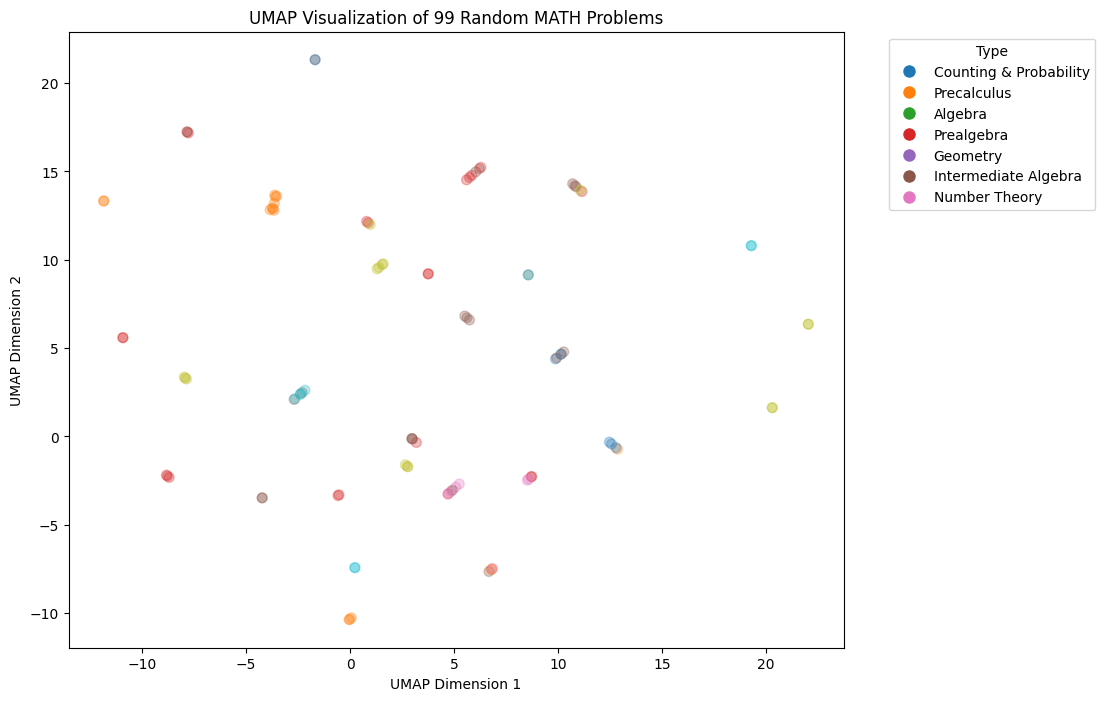

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random')
embeddings_2d = reducer.fit_transform(embeddings_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=color_values, s=50, alpha=0.3, cmap='tab10')

for i, txt in enumerate(texts):
    plt.annotate(txt[:0], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of 99 Random MATH Problems')
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=plt.cm.tab10(color_map[t]), 
                      markersize=10, label=t) 
           for t in unique_types]
plt.legend(handles=handles, title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig("./umap_colors_level.png")

### PaCMAP

In [ ]:
np.shape(embeddings_matrix)

(99, 3072)

In [ ]:
# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0) 

X = embeddings_matrix.reshape(embeddings_matrix.shape[0], -1)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(X, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], cmap="Spectral", s=20)

ValueError: could not broadcast input array from shape (0,) into shape (60,)